# 🥩 YOLO Классификация Стейков
### Детекция + Классификация в одной модели

Использует YOLO для одновременной:
- Детекции стейков на изображении
- Классификации вида стейка
- Классификации мраморности

In [2]:
%matplotlib inline
import torch
from ultralytics import YOLO
from PIL import Image
import cv2
import matplotlib.pyplot as plt

print(f"PyTorch: {torch.__version__}")
print(f"YOLO: YOLOv11")

PyTorch: 2.7.1+cu118
YOLO: YOLOv11


In [3]:
# Загрузка моделей
YOLO_MODEL = 'best_steak_detector.pt'  # YOLO для детекции
STEAK_MODEL = 'sdinov2_steak_model.pth'  # Классификация вида
MARB_MODEL = 'marbling_dinov2_model.pth'  # Классификация мраморности

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Загрузка YOLO
yolo = YOLO(YOLO_MODEL)
yolo.to(device)

Using device: cuda


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_runnin

In [4]:
# Тестирование
IMAGE_PATH = 'temp_69l-4zvyLwI_2880.jpg'  # Ваш путь к изображению

results = yolo.predict(IMAGE_PATH, conf=0.5, iou=0.5, verbose=False)[0]

if results.boxes is not None:
    boxes = results.boxes.xyxy.cpu().numpy()
    scores = results.boxes.conf.cpu().numpy()
    labels = results.boxes.cls.cpu().numpy()
    
    print(f"Found {len(boxes)} steaks:")
    for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
        print(f"  Steak {i+1}: {score:.2%} confidence")
        print(f"    Box: {box}")
else:
    print("No steaks detected")

Found 2 steaks:
  Steak 1: 93.37% confidence
    Box: [     2011.9      837.17      3689.6      2556.1]
  Steak 2: 87.79% confidence
    Box: [     1517.3      232.41      2941.1      1363.9]


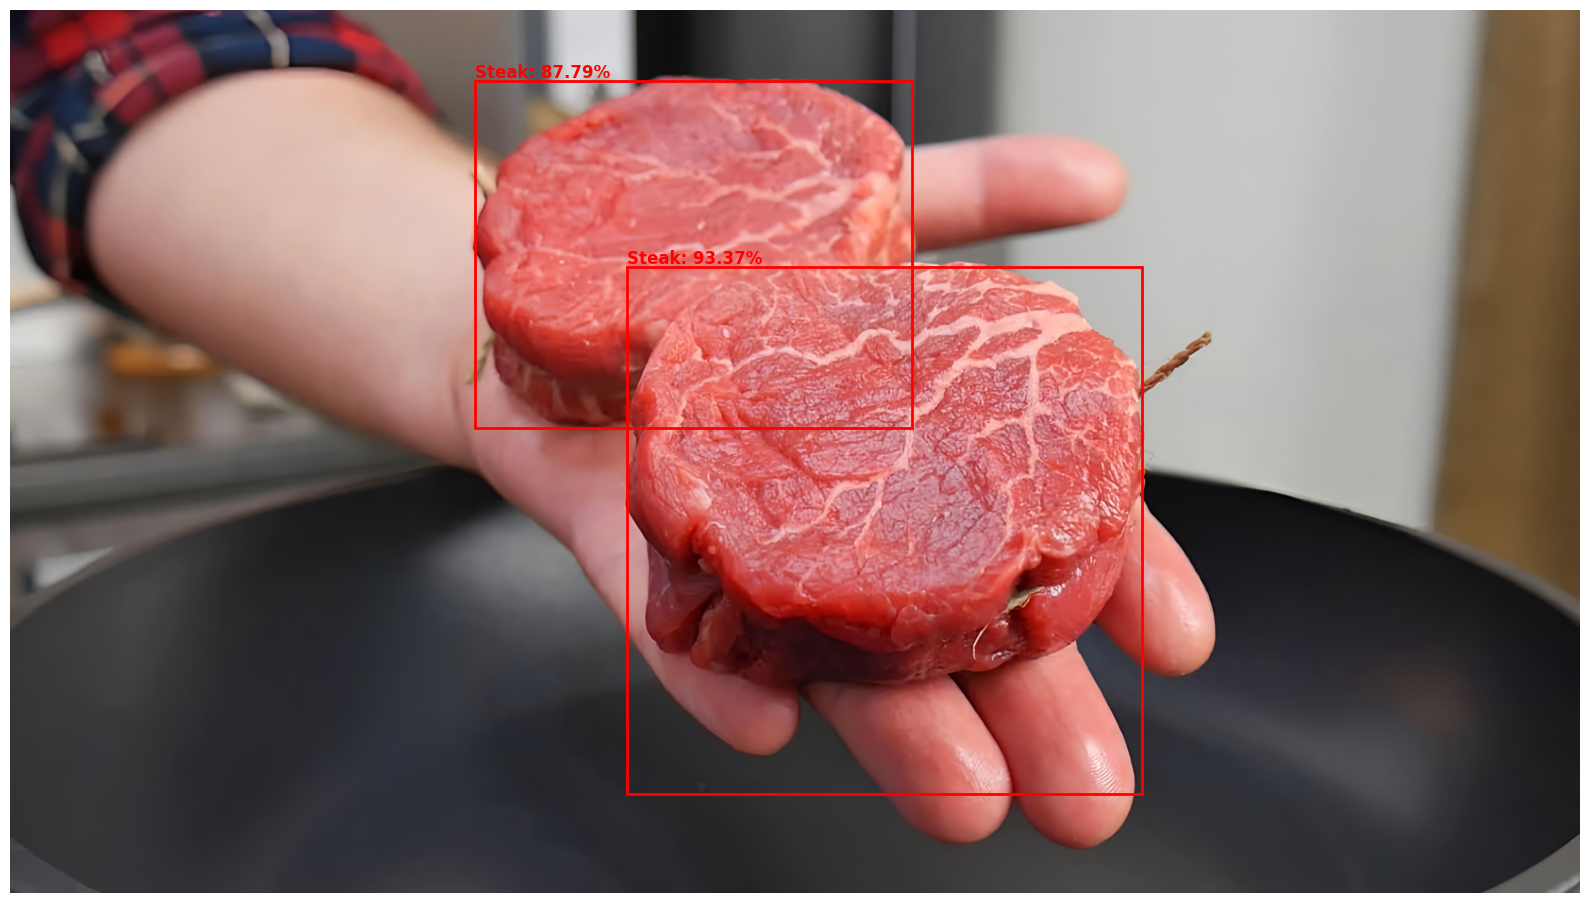

In [5]:
# Визуализация
image = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.imshow(image_rgb)

if results.boxes is not None:
    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2)
        ax.add_patch(rect)
        ax.text(x1, y1-10, f'Steak: {score:.2%}', color='red', fontsize=12, fontweight='bold')

ax.axis('off')
plt.tight_layout()
plt.show()